# 06 - SHAP + Cost-Sensitive Evaluation

Notebook n?y ??c artefact t? 03-05, gi?i th?ch m? h?nh XGBoost+SMOTE b?ng SHAP v? ??nh gi? chi ph? nghi?p v? gi?a Decision Tree baseline v? XGBoost+SMOTE.


In [1]:

# ==== SETUP ====
# Run order: 01_eda -> 02_feature_engineering -> 03_prepare_dataset -> 04_baseline_models -> 05_extension_smote_xgboost -> 06_shap_cost_sensitive
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'

sys.path.append(str(PROJECT_ROOT / 'src'))
from evaluation import evaluate_model, print_metrics_table

processed_path = DATA_DIR / 'processed_split.pkl'
results_dir = PROJECT_ROOT / 'results'
required_files = [
    processed_path,
    results_dir / 'baseline_models.pkl',
    results_dir / 'baseline_results.csv',
    results_dir / 'xgb_plain_model.pkl',
    results_dir / 'xgb_smote_model.pkl',
    results_dir / 'xgb_vs_xgb_smote_comparison.csv',
]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required artifact(s): ' + ', '.join(missing))

# Load ??ng dict ?? l?u t? 03_prepare_dataset.ipynb.
data = joblib.load(processed_path)
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

baseline_models = joblib.load(results_dir / 'baseline_models.pkl')
baseline_results = pd.read_csv(results_dir / 'baseline_results.csv')
xgb_plain_model = joblib.load(results_dir / 'xgb_plain_model.pkl')
xgb_smote_model = joblib.load(results_dir / 'xgb_smote_model.pkl')
xgb_results = pd.read_csv(results_dir / 'xgb_vs_xgb_smote_comparison.csv')

print('Ty le fraud trong y_test:', y_test.mean())
print('\nBaseline metrics:')
print(baseline_results)
print('\nXGBoost metrics:')
print(xgb_results)

best_model = xgb_smote_model
best_model_name = 'XGBoost + SMOTE'
print('\nModel dung cho SHAP:', best_model_name, '-', type(best_model).__name__)
print('X_test shape:', X_test.shape)


Ty le fraud trong y_test: 0.0012911347840983745

Baseline metrics:
                 model  accuracy  precision  recall      f1  roc_auc  pr_auc  \
0  Logistic Regression    0.9493     0.0239  0.9610  0.0467   0.9908  0.5806   
1                  KNN    0.9991     1.0000  0.3231  0.4884   0.8073  0.4906   
2        Decision Tree    1.0000     0.9964  0.9976  0.9970   0.9988  0.9939   
3        Random Forest    1.0000     1.0000  0.9976  0.9988   0.9997  0.9982   

   train_time_sec  predict_time_sec                          evaluation_scope  
0          17.322             0.169                                 full_test  
1           0.234             9.479  stratified_sample_train_50000_test_50000  
2         150.973             0.366                                 full_test  
3         352.238             5.027                                 full_test  

XGBoost metrics:
                             model  accuracy  precision  recall      f1  \
0  XGBoost (no imbalance handling)    1

SHAP values shape: (5000, 15)


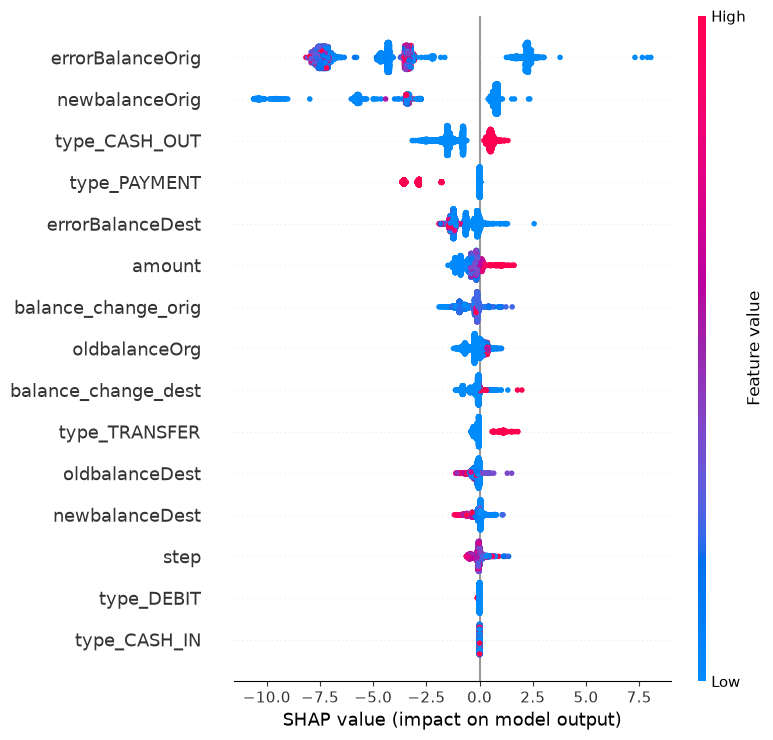

In [2]:

# ==== SHAP summary plot ====
# D?ng TreeExplainer cho XGBoost v? sample test ?? gi?m th?i gian t?nh to?n.
explainer = shap.TreeExplainer(best_model)
X_test_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print('SHAP values shape:', np.asarray(shap_values).shape)

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig(results_dir / 'shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [3]:

# ==== Ch?n case TP/FN ?? gi?i th?ch c?c b? ====
y_pred_sample = best_model.predict(X_test_sample)
y_test_sample = y_test.loc[X_test_sample.index]

tp_mask = (y_test_sample == 1) & (y_pred_sample == 1)
fn_mask = (y_test_sample == 1) & (y_pred_sample == 0)

tp_idx = X_test_sample.index[tp_mask][0] if tp_mask.sum() > 0 else None
fn_idx = X_test_sample.index[fn_mask][0] if fn_mask.sum() > 0 else None

if fn_idx is None:
    print('Khong tim thay False Negative trong sample - tim rieng trong toan bo fraud cases...')
    fraud_idx_all = y_test[y_test == 1].index
    y_pred_all_fraud = best_model.predict(X_test.loc[fraud_idx_all])
    fn_idx_candidates = fraud_idx_all[y_pred_all_fraud == 0]
    if len(fn_idx_candidates) == 0:
        print('Model khong bo sot fraud case nao tren toan bo test set (Recall = 100%).')
    else:
        fn_idx = fn_idx_candidates[0]
        if fn_idx not in X_test_sample.index:
            X_test_sample = pd.concat([X_test_sample, X_test.loc[[fn_idx]]])
            shap_values_fn_extra = explainer.shap_values(X_test.loc[[fn_idx]])

if tp_idx is None:
    print('Khong tim thay True Positive trong sample - tim rieng trong toan bo fraud cases...')
    fraud_idx_all = y_test[y_test == 1].index
    y_pred_all_fraud = best_model.predict(X_test.loc[fraud_idx_all])
    tp_idx_candidates = fraud_idx_all[y_pred_all_fraud == 1]
    if len(tp_idx_candidates) > 0:
        tp_idx = tp_idx_candidates[0]
        if tp_idx not in X_test_sample.index:
            X_test_sample = pd.concat([X_test_sample, X_test.loc[[tp_idx]]])
            shap_values_tp_extra = explainer.shap_values(X_test.loc[[tp_idx]])

print('True Positive case index:', tp_idx)
print('False Negative case index:', fn_idx)


Khong tim thay False Negative trong sample - tim rieng trong toan bo fraud cases...
True Positive case index: 6020257
False Negative case index: 543928


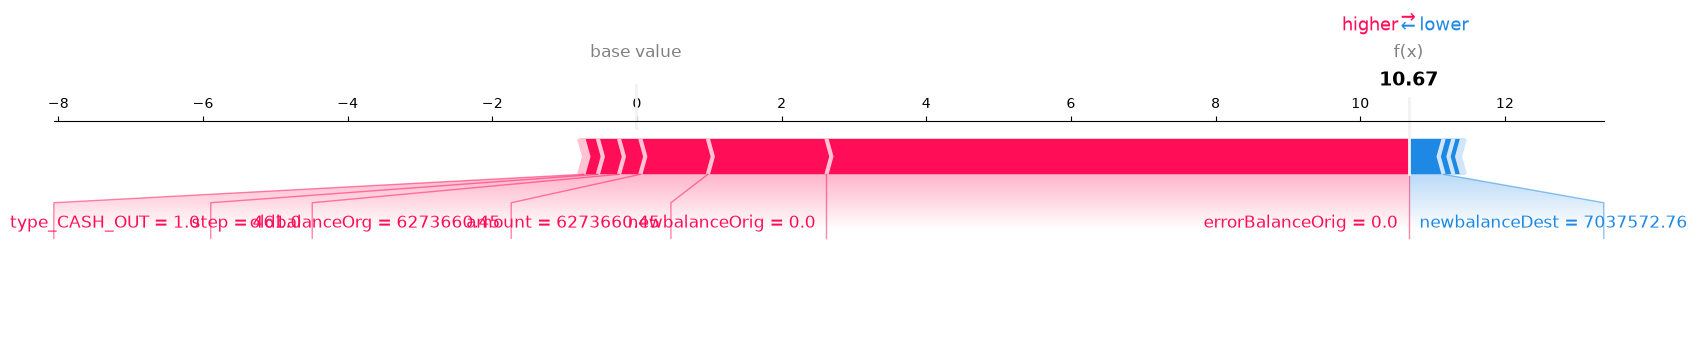

In [4]:

# ==== Force plot: True Positive ====
def expected_value_for_binary(explainer):
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, tuple, np.ndarray)) and np.asarray(expected_value).ndim > 0:
        return np.asarray(expected_value).ravel()[-1]
    return expected_value

base_value = expected_value_for_binary(explainer)

if tp_idx is None:
    print('Khong tim thay True Positive de ve force plot.')
else:
    tp_position = X_test_sample.index.get_loc(tp_idx)
    if 'shap_values_tp_extra' in dir() and tp_position == len(X_test_sample) - 1 and tp_position >= len(shap_values):
        tp_shap_value = shap_values_tp_extra[0]
    else:
        tp_shap_value = shap_values[tp_position]

    shap.force_plot(
        base_value,
        tp_shap_value,
        X_test_sample.iloc[tp_position],
        matplotlib=True,
        show=False
    )
    plt.savefig(results_dir / 'shap_force_plot_TP.png', dpi=150, bbox_inches='tight')
    plt.show()


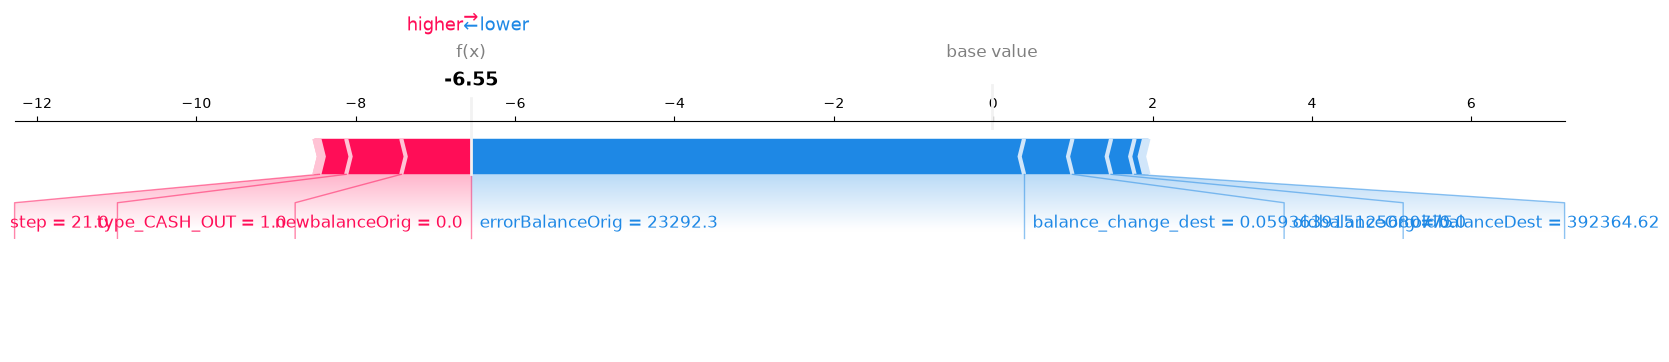

In [5]:

# ==== Force plot: False Negative ====
if fn_idx is None:
    print('Model khong co False Negative tren toan bo test set - khong co case de ve force plot.')
else:
    fn_position = X_test_sample.index.get_loc(fn_idx)
    if 'shap_values_fn_extra' in dir() and fn_position == len(X_test_sample) - 1 and fn_position >= len(shap_values):
        fn_shap_value = shap_values_fn_extra[0]
    else:
        fn_shap_value = shap_values[fn_position]

    shap.force_plot(
        base_value,
        fn_shap_value,
        X_test_sample.iloc[fn_position],
        matplotlib=True,
        show=False
    )
    plt.savefig(results_dir / 'shap_force_plot_FN.png', dpi=150, bbox_inches='tight')
    plt.show()


## Cost-Sensitive Evaluation

Gi? ??nh nghi?p v?: m?i c?nh b?o sai (`FP`) t?o chi ph? ?i?u tra th? c?ng, c?n m?i giao d?ch gian l?n b? b? s?t (`FN`) g?y t?n th?t l?n h?n. V? ch?a c? s? ti?n t?n th?t th?t t? ng?n h?ng, notebook d?ng ma tr?n chi ph? chu?n h?a `FP = 1`, `FN = 50` v? ch?y th?m ph?n t?ch ?? nh?y theo nhi?u m?c `FN/FP`.


In [6]:

# ==== Cost matrix + metric function ====
FP_INVESTIGATION_COST = 1
FN_MISSED_FRAUD_COST = 50

cost_matrix = pd.DataFrame(
    [[0, FP_INVESTIGATION_COST], [FN_MISSED_FRAUD_COST, 0]],
    index=['Actual normal (0)', 'Actual fraud (1)'],
    columns=['Predicted normal (0)', 'Predicted fraud (1)']
)
print('Cost matrix:')
print(cost_matrix)

def cost_sensitive_metrics(model, X_eval, y_true, model_name, fp_cost=1, fn_cost=50, threshold=0.5):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
        y_pred = (y_score >= threshold).astype(int)
    else:
        y_score = None
        y_pred = model.predict(X_eval)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_cost = fp * fp_cost + fn * fn_cost
    fraud_cases = fn + tp
    flagged_cases = fp + tp

    return {
        'model': model_name,
        'threshold': threshold,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'fp_cost': fp_cost,
        'fn_cost': fn_cost,
        'total_cost': int(total_cost),
        'cost_per_transaction': total_cost / len(y_true),
        'missed_fraud_rate': fn / fraud_cases if fraud_cases else 0,
        'investigation_rate': flagged_cases / len(y_true),
    }


Cost matrix:
                   Predicted normal (0)  Predicted fraud (1)
Actual normal (0)                     0                    1
Actual fraud (1)                     50                    0


In [7]:

# ==== So s?nh m?c ??nh threshold 0.5: Decision Tree vs XGBoost+SMOTE ====
decision_tree_model = baseline_models['decision_tree']

cost_default = pd.DataFrame([
    cost_sensitive_metrics(decision_tree_model, X_test, y_test, 'Decision Tree', FP_INVESTIGATION_COST, FN_MISSED_FRAUD_COST),
    cost_sensitive_metrics(xgb_smote_model, X_test, y_test, 'XGBoost + SMOTE', FP_INVESTIGATION_COST, FN_MISSED_FRAUD_COST),
])

cost_default = cost_default.sort_values('total_cost').reset_index(drop=True)
print(cost_default)
cost_default.to_csv(results_dir / 'cost_sensitive_comparison.csv', index=False)
print('Da luu ../results/cost_sensitive_comparison.csv')


             model  threshold       tn   fp  fn    tp  fp_cost  fn_cost  \
0    Decision Tree        0.5  1270875    6   4  1639        1       50   
1  XGBoost + SMOTE        0.5  1270766  115   3  1640        1       50   

   total_cost  cost_per_transaction  missed_fraud_rate  investigation_rate  
0         206              0.000162           0.002435            0.001293  
1         265              0.000208           0.001826            0.001379  
Da luu ../results/cost_sensitive_comparison.csv


             model  fn_cost   fp  fn  total_cost  cost_per_transaction  \
0    Decision Tree       10    6   4          46              0.000036   
1  XGBoost + SMOTE       10  115   3         145              0.000114   
2    Decision Tree       25    6   4         106              0.000083   
3  XGBoost + SMOTE       25  115   3         190              0.000149   
4    Decision Tree       50    6   4         206              0.000162   
5  XGBoost + SMOTE       50  115   3         265              0.000208   
6    Decision Tree      100    6   4         406              0.000319   
7  XGBoost + SMOTE      100  115   3         415              0.000326   
8    Decision Tree      200    6   4         806              0.000633   
9  XGBoost + SMOTE      200  115   3         715              0.000562   

   missed_fraud_rate  investigation_rate  
0           0.002435            0.001293  
1           0.001826            0.001379  
2           0.002435            0.001293  
3           0

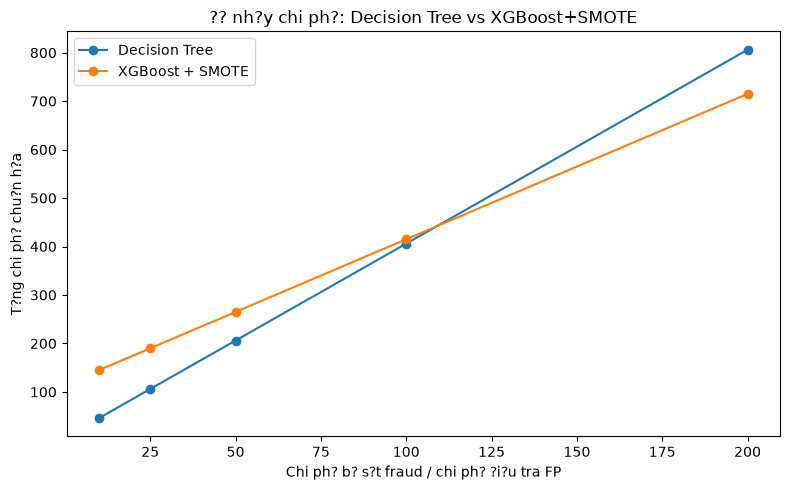

In [8]:

# ==== Ph?n t?ch ?? nh?y: FN ??t h?n FP bao nhi?u l?n th? model n?o th?ng? ====
fn_cost_grid = [10, 25, 50, 100, 200]
sensitivity_rows = []
for fn_cost in fn_cost_grid:
    sensitivity_rows.append(cost_sensitive_metrics(decision_tree_model, X_test, y_test, 'Decision Tree', 1, fn_cost))
    sensitivity_rows.append(cost_sensitive_metrics(xgb_smote_model, X_test, y_test, 'XGBoost + SMOTE', 1, fn_cost))

cost_sensitivity = pd.DataFrame(sensitivity_rows)
print(cost_sensitivity[['model', 'fn_cost', 'fp', 'fn', 'total_cost', 'cost_per_transaction', 'missed_fraud_rate', 'investigation_rate']])
cost_sensitivity.to_csv(results_dir / 'cost_sensitive_sensitivity.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, group in cost_sensitivity.groupby('model'):
    ax.plot(group['fn_cost'], group['total_cost'], marker='o', label=model_name)
ax.set_xlabel('Chi ph? b? s?t fraud / chi ph? ?i?u tra FP')
ax.set_ylabel('T?ng chi ph? chu?n h?a')
ax.set_title('?? nh?y chi ph?: Decision Tree vs XGBoost+SMOTE')
ax.legend()
plt.tight_layout()
plt.savefig(results_dir / 'cost_sensitive_sensitivity.png', dpi=150)
plt.show()


In [9]:

# ==== Optional: t?m threshold chi ph? th?p nh?t cho t?ng model ====
thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
threshold_rows = []
for threshold in thresholds:
    threshold_rows.append(cost_sensitive_metrics(decision_tree_model, X_test, y_test, 'Decision Tree', FP_INVESTIGATION_COST, FN_MISSED_FRAUD_COST, threshold))
    threshold_rows.append(cost_sensitive_metrics(xgb_smote_model, X_test, y_test, 'XGBoost + SMOTE', FP_INVESTIGATION_COST, FN_MISSED_FRAUD_COST, threshold))

threshold_sweep = pd.DataFrame(threshold_rows)
best_threshold_by_model = threshold_sweep.loc[threshold_sweep.groupby('model')['total_cost'].idxmin()].sort_values('total_cost')
print('Best threshold theo tong chi phi:')
print(best_threshold_by_model[['model', 'threshold', 'fp', 'fn', 'tp', 'total_cost', 'cost_per_transaction', 'missed_fraud_rate', 'investigation_rate']])

threshold_sweep.to_csv(results_dir / 'cost_sensitive_threshold_sweep.csv', index=False)
best_threshold_by_model.to_csv(results_dir / 'cost_sensitive_best_thresholds.csv', index=False)
print('Da luu threshold sweep va best thresholds vao ../results/')


Best threshold theo tong chi phi:
              model  threshold  fp  fn    tp  total_cost  \
37  XGBoost + SMOTE       0.95   3   4  1639         203   
0     Decision Tree       0.05   6   4  1639         206   

    cost_per_transaction  missed_fraud_rate  investigation_rate  
37              0.000160           0.002435            0.001290  
0               0.000162           0.002435            0.001293  
Da luu threshold sweep va best thresholds vao ../results/
